In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import sys

In [7]:
sys.path.append('/ix/djishnu/alw399/SpaceTravLR/src')

In [4]:
%matplotlib inline

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

In [5]:
# there are cell-intrinsic networks, and cell-extrinsic 
# cell-extrinsic ligand expression is from other cells
# bottom up network or top down network? "sphere of influence"
# ligand --> TF/receptor 
# or TF/receptor --> ligand --> TF/receptor

In [8]:
training_dir = '/ix/djishnu/shared/djishnu_kor11/training_data_revision/tfh_network/mouse_lymph_slideseq_D5_1/chunk_0'
adata = sc.read_h5ad(os.path.join(training_dir, 'input_data/_adata.h5ad'))
adata

AnnData object with n_obs × n_vars = 12681 × 3354
    obs: 'celltype_label_tangram', 'cell_type', 'cell_type_int'
    uns: 'cell_thresholds', 'neighbors', 'received_ligands', 'received_ligands_tfl', 'umap'
    obsm: 'X_pca', 'X_spatial', 'X_umap', 'spatial', 'spatial_unscaled', 'tangram_ct_pred'
    varm: 'PCs'
    layers: 'imputed_count', 'normalized_count', 'raw_count'
    obsp: 'connectivities', 'distances'

In [9]:
# from SpaceTravLR.gene_factory import GeneFactory
# gf = GeneFactory.from_json(adata, f'{training_dir}/betadata/run_params.json')
# gf.load_betas(float16=True, obs_names=None)

In [10]:
# compute delta wL 
# gf.current_target = gene
# sim_wL = gf._compute_weighted_ligands(delta_df, adata.uns['cell_thresholds'], gf.ligands)
# sim_wL.head()

In [53]:
gene = 'Nr3c1'
# gene = 'Bcl6'

In [54]:
# gex_out, gradients = gf.perturb_track(
#     target=gene,
#     n_propagation=4,
#     gene_expr=0,
# )

In [55]:
save_dir = training_dir + '/genome_screens'

import pickle
with open(f'{save_dir}/{gene}_4n_0x_gradients.pkl', 'rb') as f:
    gradients = pickle.load(f)
gradients.keys()

dict_keys(['A2m', 'Adam15', 'Adam33', 'Adamts15', 'Adamts16', 'Adamts8', 'Adamts9', 'Adat3', 'Adcy4', 'Adcy5', 'Adcy9', 'Adgrd1', 'Adgre5', 'Adgrf3', 'Adgrf5', 'Adgrl2', 'Adgrv1', 'Adh1', 'Adh6-ps1', 'Adhfe1', 'Adig', 'Adipoq', 'Adipor1', 'Adora1', 'Adora3', 'Adpgk', 'Adprhl1', 'Adra1b', 'Adra2a', 'Adrb1', 'Adrb3', 'Adssl1', 'Adtrp', 'Afap1l1', 'Afap1l2', 'Aga', 'Ager', 'Agfg2', 'Agpat2', 'Agtr1a', 'Ahcyl2', 'Ahdc1', 'Ahi1', 'Ahnak', 'Ahr', 'Aicda', 'Aifm2', 'Aig1', 'Ajap1', 'Ak1', 'Akap12', 'Akap9', 'Akr1b8', 'Akr1c14', 'Akr1cl', 'Akr1e1', 'Alas2', 'Aldh1a7', 'Aldh2', 'Aldh3a1', 'Aldh3a2', 'Aldh3b2', 'Aldh6a1', 'Aldh7a1', 'Alg11', 'Alg14', 'Alkbh2', 'Alkbh8', 'Alox15', 'Alox5ap', 'Als2', 'Als2cr12', 'Amdhd1', 'Amotl1', 'Amotl2', 'Amph', 'Amy1', 'Anapc10', 'Anapc4', 'Ang', 'Angpt1', 'Angptl4', 'Ankdd1b', 'Ankfn1', 'Ankhd1', 'Ankrd1', 'Ankrd13b', 'Ankrd2', 'Ankrd26', 'Ankrd45', 'Ankrd46', 'Anks1b', 'Anks6', 'Ano1', 'Anxa1', 'Anxa2', 'Anxa4', 'Anxa8', 'Aoc2', 'Aoc3', 'Aox1', 'Aox4', 'Ap5

In [56]:
gradients.keys()

dict_keys(['A2m', 'Adam15', 'Adam33', 'Adamts15', 'Adamts16', 'Adamts8', 'Adamts9', 'Adat3', 'Adcy4', 'Adcy5', 'Adcy9', 'Adgrd1', 'Adgre5', 'Adgrf3', 'Adgrf5', 'Adgrl2', 'Adgrv1', 'Adh1', 'Adh6-ps1', 'Adhfe1', 'Adig', 'Adipoq', 'Adipor1', 'Adora1', 'Adora3', 'Adpgk', 'Adprhl1', 'Adra1b', 'Adra2a', 'Adrb1', 'Adrb3', 'Adssl1', 'Adtrp', 'Afap1l1', 'Afap1l2', 'Aga', 'Ager', 'Agfg2', 'Agpat2', 'Agtr1a', 'Ahcyl2', 'Ahdc1', 'Ahi1', 'Ahnak', 'Ahr', 'Aicda', 'Aifm2', 'Aig1', 'Ajap1', 'Ak1', 'Akap12', 'Akap9', 'Akr1b8', 'Akr1c14', 'Akr1cl', 'Akr1e1', 'Alas2', 'Aldh1a7', 'Aldh2', 'Aldh3a1', 'Aldh3a2', 'Aldh3b2', 'Aldh6a1', 'Aldh7a1', 'Alg11', 'Alg14', 'Alkbh2', 'Alkbh8', 'Alox15', 'Alox5ap', 'Als2', 'Als2cr12', 'Amdhd1', 'Amotl1', 'Amotl2', 'Amph', 'Amy1', 'Anapc10', 'Anapc4', 'Ang', 'Angpt1', 'Angptl4', 'Ankdd1b', 'Ankfn1', 'Ankhd1', 'Ankrd1', 'Ankrd13b', 'Ankrd2', 'Ankrd26', 'Ankrd45', 'Ankrd46', 'Anks1b', 'Anks6', 'Ano1', 'Anxa1', 'Anxa2', 'Anxa4', 'Anxa8', 'Aoc2', 'Aoc3', 'Aox1', 'Aox4', 'Ap5

In [57]:
cois = adata.obs[adata.obs.cell_type == 'Tfh'].index
# delta_df = delta_df.loc[cois]
# end_nodes = delta_df.mean().sort_values(ascending=False, key=abs).head(10)
# end_nodes

end_node = 'Il21'

In [58]:
# think of gradient accumulation from the perturbation of interest to CXCR4 
# IL21 --> CXCR4 


In [59]:
adata.obs.cell_type.value_counts()

cell_type
B            6516
Resting T    2232
CD8+ T       1282
Tfh          1222
Treg         1012
Th2           282
DC            135
Name: count, dtype: int64

In [60]:
ligands = list(adata.uns['received_ligands'].columns)
len(ligands)

138

In [61]:
ccc = adata.uns['cell_thresholds'].columns[adata.uns['cell_thresholds'].sum() != 0]
receptors = set(ccc) - set(ligands)
len(receptors)

96

In [62]:
import networkx as nx 
from tqdm import tqdm

G = nx.DiGraph()

target_gene = end_node
n_top = 5
next_layer = [target_gene]
edges = []

for i in tqdm(range(5)):  # n hops
    
    curr_layer = next_layer.copy()

    for node in curr_layer:
        if node in G.nodes():
            continue

        upstream_df = gradients[node].loc[cois]
        upstream_df.columns = [x.split('_')[1] for x in upstream_df.columns]
        tmp = upstream_df.mean(axis=0).sort_values(ascending=False, key=abs)
        tmp = tmp[tmp.abs() > 1e-6]
        top_nodes = tmp.head(n_top)

        edges.extend([(top_node, node, weight) for top_node, weight in top_nodes.items()])
        next_layer.extend(top_nodes.index)
        G.add_node(node, layer=4-i+1)

100%|██████████| 5/5 [00:00<00:00, 54.00it/s]


In [63]:
G.add_weighted_edges_from(edges)

In [64]:
distances = nx.single_source_shortest_path_length(G, gene, cutoff=5)
# for node, dist in distances.items():
#     G.nodes[node]['layer'] = dist

G.remove_nodes_from(set(G.nodes()) - set(distances.keys()))

In [65]:
# source perturbation node
G.nodes[gene]['layer'] = 0
# target node
G.nodes[end_node]['layer'] = 5
G.nodes(data=True)

NodeDataView({'Il21': {'layer': 5}, 'Nr3c1': {'layer': 0}, 'Gata3': {'layer': 4}, 'Tcf7': {'layer': 4}, 'Mxi1': {'layer': 4}, 'Nfatc1': {'layer': 4}, 'Nfatc3': {'layer': 3}, 'Sp1': {'layer': 3}, 'Foxp1': {'layer': 3}, 'Stat3': {'layer': 3}, 'Gabpa': {'layer': 3}, 'Klf2': {'layer': 3}, 'Stat2': {'layer': 3}, 'Stat1': {'layer': 3}, 'Irf4': {'layer': 3}, 'Klf3': {'layer': 3}, 'Rxra': {'layer': 3}, 'Lef1': {'layer': 3}, 'Ctcf': {'layer': 3}, 'Sp3': {'layer': 3}, 'Stat6': {'layer': 3}, 'Rest': {'layer': 3}, 'Maf': {'layer': 2}, 'Fli1': {'layer': 2}, 'Fosl2': {'layer': 2}, 'Nfyb': {'layer': 2}, 'E2f4': {'layer': 2}, 'Vezf1': {'layer': 2}, 'Jund': {'layer': 2}, 'Gtf2i': {'layer': 2}, 'Klf9': {'layer': 2}, 'Erg': {'layer': 1}, 'Pax5': {'layer': 1}, 'Cebpb': {'layer': 1}, 'Junb': {'layer': 1}})

In [66]:
from collections import Counter
nodes_per_layer = Counter(d['layer'] for n, d in G.nodes(data=True))
nodes_per_layer

Counter({3: 16, 2: 9, 4: 4, 1: 4, 5: 1, 0: 1})

In [67]:
from collections import defaultdict

pos = {}
nodes_by_layer = defaultdict(list)
for node, data in G.nodes(data=True):
    nodes_by_layer[data['layer']].append(node)

for layer, nodes in nodes_by_layer.items():
    n = len(nodes)
    # Spread nodes evenly from y = -0.5 to y = +0.5 for each layer (can tweak spread)
    y_positions = np.linspace(-0.5, 0.5, n) if n > 1 else [0.0]
    for node, y in zip(nodes, y_positions):
        pos[node] = (layer, y)


In [68]:
network_genes = np.loadtxt('network_genes.txt', dtype=str)
len(network_genes)

290

In [69]:
scenic_genes = np.loadtxt('scenic_genes.txt', dtype=str)
len(scenic_genes)

1970

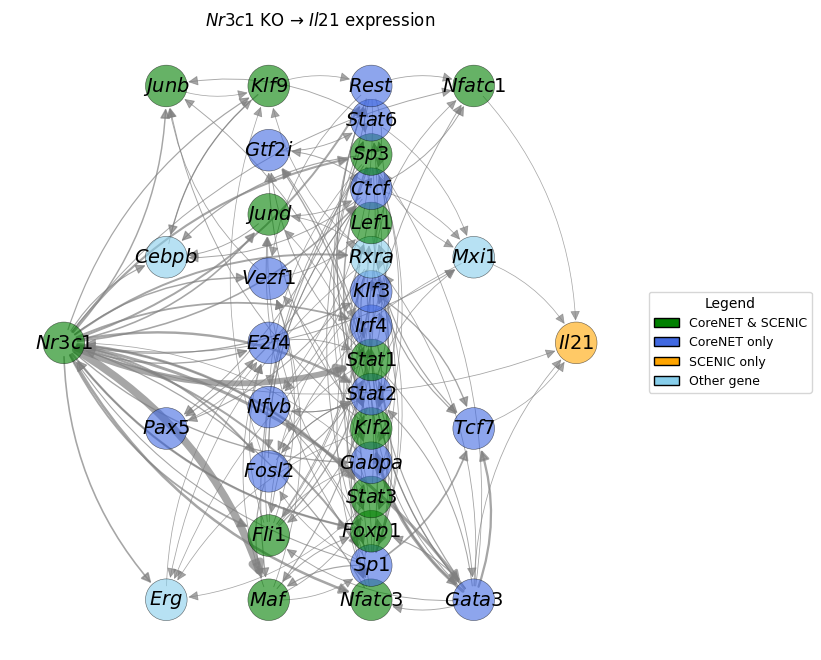

In [70]:
plt.figure(figsize=(8, 8))

# spring layout
# pos = nx.spring_layout(G, seed=42) 

# hierarchical layout
# pos = nx.multipartite_layout(G, subset_key='layer')
# pos = {k: (v[0] + random.uniform(-0.1, 0.1), v[1]) for k, v in pos.items()}

# manual layout
# pos = {node: (G.nodes[node]['layer'], random.uniform(-0.1, 0.1)) for node in G.nodes()}

node_colors = []
for node in G.nodes():
    if node in network_genes and node in scenic_genes:
        node_colors.append('green')
    elif node in network_genes:
        node_colors.append('royalblue')
    elif node in scenic_genes:
        node_colors.append('orange')
    else: 
        # not in either network or scenic
        node_colors.append('skyblue')

# Draw nodes with the assigned colors
nx.draw_networkx_nodes(
    G, pos, 
    node_size=900, 
    node_color=node_colors, 
    edgecolors='black', 
    linewidths=0.4,
    alpha=0.6,
)

# Prepare edge weights and edge colors based on sign of weight
edges_data = list(G.edges(data=True))
edges_weights = []
edges_colors = []
for _, _, d in edges_data:
    w = d['weight'] if isinstance(d, dict) and 'weight' in d else 1.0
    edges_weights.append(w)
    edges_colors.append("gray")
    # if w < 0:
    #     edges_colors.append("skyblue")
    # else:
    #     edges_colors.append("salmon")

# Normalize weights for line thickness
max_w = max(abs(float(w)) for w in edges_weights) if edges_weights else 1.0
widths = [abs(float(w))/(max_w+1e-10)*5+0.5 for w in edges_weights]

# Draw curved edges to prevent overlap using connectionstyle
# Create a list of connection styles for each edge: alternate sign for nice spacings if multiple edges between same nodes
import itertools
connectionstyles = []
# Cycle through two arc rad values (positive and negative) to split bidirectional/parallel edges
for idx, (u, v, d) in enumerate(edges_data):
    # Alternate the direction of curve for visually adjacent edges
    arc_rad = 0.2 if idx % 2 == 0 else -0.2
    connectionstyles.append(f"arc3,rad={arc_rad}")

for i, ((u, v, d), color, width, connstyle) in enumerate(zip(edges_data, edges_colors, widths, connectionstyles)):
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        width=width,
        edge_color=color,
        arrowstyle='-|>',
        arrowsize=15,
        alpha=0.7,
        connectionstyle=connstyle,
        min_source_margin=10,
        min_target_margin=16
    )

# Draw node labels - capitalized and italicized
labels = {node: f"$\mathit{{{node.capitalize()}}}$" for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=14)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib

# Legend for nodes
node_patches = [
    mpatches.Patch(facecolor='green', edgecolor='black', label='CoreNET & SCENIC'),
    mpatches.Patch(facecolor='royalblue', edgecolor='black', label='CoreNET only'),
    mpatches.Patch(facecolor='orange', edgecolor='black', label='SCENIC only'),
    mpatches.Patch(facecolor='skyblue', edgecolor='black', label='Other gene')
]

# Legend for edges
# edge_patches = [
#     Line2D([0], [0], color='salmon', lw=2, label='Positive effect'),
#     Line2D([0], [0], color='skyblue', lw=2, label='Negative effect')
# ]

plt.legend(handles=node_patches,  #+ edge_patches, 
           loc='center left', 
           bbox_to_anchor=(1.02, 0.5),
           frameon=True, fontsize=9, ncol=1, title="Legend", title_fontsize=10)


plt.title(f"$\mathit{{{gene.capitalize()}}}$ KO → $\mathit{{{target_gene.capitalize()}}}$ expression")
plt.axis('off')
plt.savefig(f'figures/mouse_lymph_slideseq_D5_1_propagation_{gene}to{target_gene}.svg', dpi=300, bbox_inches='tight', format='svg', transparent=True)
plt.show()

In [71]:
print(gene)
sim_gex = pd.read_parquet(training_dir + f'/genome_screens/{gene}_4n_0x.parquet')
sim_gex.shape

orig_gex = adata.to_df(layer='imputed_count').loc[cois]
sim_gex = sim_gex.loc[cois]

orig_il21 = orig_gex[end_node]
sim_il21 = sim_gex[end_node]

pseudocount = 1e-8
logfc_il21 = np.log2((sim_il21 + pseudocount) / (orig_il21 + pseudocount))

from scipy import stats
t_stat, p_value = stats.ttest_1samp(logfc_il21, 0)

mean_logfc = logfc_il21.mean()
print(f"{end_node} log2FC: {mean_logfc:.3f}")
print(f"One-sample t-test p-value for {end_node} log2FC ≠ 0: {p_value:.3g}")


Nr3c1


Il21 log2FC: -0.350
One-sample t-test p-value for Il21 log2FC ≠ 0: 1.25e-14


In [52]:
print(gene)
sim_gex = pd.read_parquet(training_dir + f'/genome_screens/{gene}_4n_0x.parquet')
sim_gex.shape

orig_gex = adata.to_df(layer='imputed_count').loc[cois]
sim_gex = sim_gex.loc[cois]

orig_il21 = orig_gex[end_node]
sim_il21 = sim_gex[end_node]

pseudocount = 1e-8
logfc_il21 = np.log2((sim_il21 + pseudocount) / (orig_il21 + pseudocount))

from scipy import stats
t_stat, p_value = stats.ttest_1samp(logfc_il21, 0)

mean_logfc = logfc_il21.mean()
print(f"{end_node} log2FC: {mean_logfc:.3f}")
print(f"One-sample t-test p-value for {end_node} log2FC ≠ 0: {p_value:.3g}")


Bcl6
Il21 log2FC: -0.076
One-sample t-test p-value for Il21 log2FC ≠ 0: 0.000214
